In [1]:
from astropy.table import Table
import galsim
import numpy as np

cosmos_cat_fname = "/home/adfield/ShearNet/cosmos15_superbit2023_phot_shapes_with_sigma.csv"
cosmos_cat = Table.read(cosmos_cat_fname, format="csv")

q_raw   = np.array(cosmos_cat['c10_sersic_fit_q'],  dtype=np.float64)
phi_raw = np.array(cosmos_cat['c10_sersic_fit_phi'], dtype=np.float64)

g1_raw = []
g2_raw = []
for qi, phi_i in zip(q_raw, phi_raw):
    if qi > 1.0:
        qi = 1.0 / qi
    s = galsim.Shear(q=float(qi), beta=float(phi_i) * galsim.radians)
    g1_raw.append(s.g1)
    g2_raw.append(s.g2)
    

g1_raw = np.array(g1_raw)
g2_raw = np.array(g2_raw)

# HLR: apply the 1 arcsec physical cap, then build a validity mask.
# Non-finite or non-positive values are non-physical — we drop those rows
# from ALL arrays so that galaxy-level correspondence is never broken.
hlr_raw = np.array(cosmos_cat['c10_sersic_fit_hlr'], dtype=np.float64) * 0.03 * np.sqrt(q_raw)
hlr_raw = np.minimum(hlr_raw, 1.0)

flux_raw = np.array(cosmos_cat['crates_b'], dtype=np.float64) * 300 * 36 / 0.343

valid_mask = np.isfinite(hlr_raw) & (hlr_raw > 1e-6)

# Apply the mask uniformly — every array is filtered with the same boolean
# index so index i in q_arr always refers to the same physical galaxy as
# index i in phi_arr, g1_list, g2_list, hlr_list, and flux_list.
q_arr     = q_raw[valid_mask]
phi_arr   = phi_raw[valid_mask]
g1_list   = g1_raw[valid_mask]
g2_list   = g2_raw[valid_mask]
hlr_list  = hlr_raw[valid_mask]
flux_list = flux_raw[valid_mask]

n_raw     = len(q_raw)
n_dropped = n_raw - valid_mask.sum()
print(f"Raw catalog rows:       {n_raw}")
print(f"Dropped (invalid HLR):  {n_dropped}")
print(f"Remaining galaxies:     {len(q_arr)}")

Raw catalog rows:       518404
Dropped (invalid HLR):  99
Remaining galaxies:     518305


Flux outlier rejection comparison (post-HLR sample)
  Sample size:                 518,305

  Method A — IQR fence (k=3.5)
    log10 range kept:  [0.578, 6.016]
    Flux range kept:   [3.78, 1036453.35] counts
    Dropped:                4,174  (0.805%)

  Method B — sigma-clip (3.5σ)
    log10 range kept:  [0.872, 5.672]
    Flux range kept:   [7.44, 469821.72] counts
    Dropped:                5,230  (1.009%)


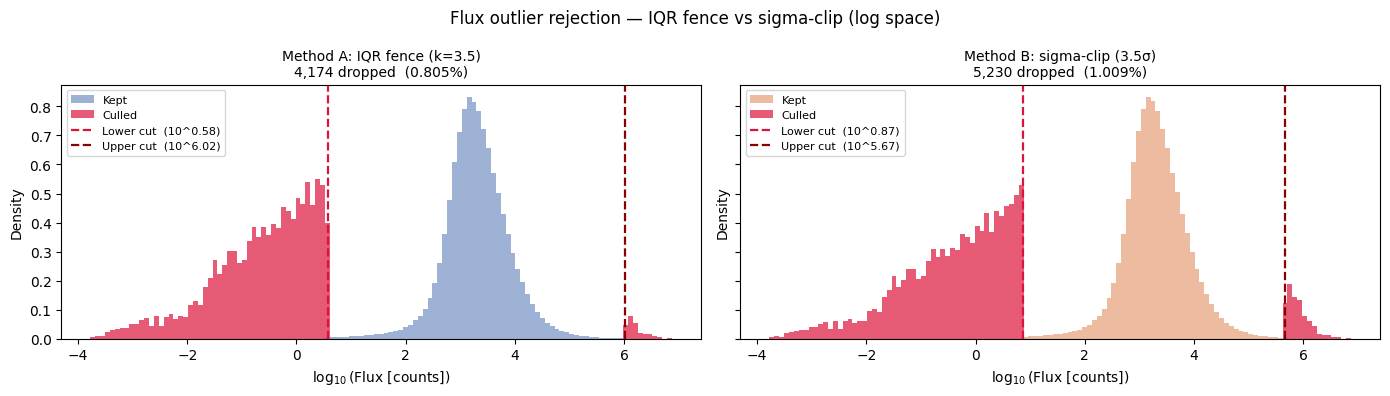

In [2]:
import matplotlib.pyplot as plt

# Work in log space on the HLR-clean sample; guard against non-positive flux
pos_mask = flux_list > 0
log_flux  = np.log10(flux_list[pos_mask])
flux_pos  = flux_list[pos_mask]

# --- Method A: Tukey IQR fence in log space (k=3, non-parametric) ---
K = 3.5
Q1, Q3 = np.percentile(log_flux, [25, 75])
IQR = Q3 - Q1
iqr_lo = Q1 - K * IQR
iqr_hi = Q3 + K * IQR
iqr_mask = (log_flux >= iqr_lo) & (log_flux <= iqr_hi)
n_iqr_dropped = (~iqr_mask).sum()

# --- Method B: sigma-clip in log space (N=3, parametric) ---
N_SIGMA  = 3.5
mu_log   = log_flux.mean()
sig_log  = log_flux.std()
sig_lo   = mu_log - N_SIGMA * sig_log
sig_hi   = mu_log + N_SIGMA * sig_log
sig_mask = (log_flux >= sig_lo) & (log_flux <= sig_hi)
n_sig_dropped = (~sig_mask).sum()

print('Flux outlier rejection comparison (post-HLR sample)')
print(f'  Sample size:              {len(log_flux):>10,}')
print()
print(f'  Method A — IQR fence (k={K})')
print(f'    log10 range kept:  [{iqr_lo:.3f}, {iqr_hi:.3f}]')
print(f'    Flux range kept:   [{10**iqr_lo:.2f}, {10**iqr_hi:.2f}] counts')
print(f'    Dropped:           {n_iqr_dropped:>10,}  ({100*n_iqr_dropped/len(log_flux):.3f}%)')
print()
print(f'  Method B — sigma-clip ({N_SIGMA}σ)')
print(f'    log10 range kept:  [{sig_lo:.3f}, {sig_hi:.3f}]')
print(f'    Flux range kept:   [{10**sig_lo:.2f}, {10**sig_hi:.2f}] counts')
print(f'    Dropped:           {n_sig_dropped:>10,}  ({100*n_sig_dropped/len(log_flux):.3f}%)')

# --- Side-by-side plot ---
bins_log = np.linspace(log_flux.min(), log_flux.max(), 120)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.suptitle(
    'Flux outlier rejection — IQR fence vs sigma-clip (log space)',
    fontsize=12
)

for ax, mask, lo, hi, label, color in [
    (axes[0], iqr_mask, iqr_lo, iqr_hi,
     f'Method A: IQR fence (k={K})\n{n_iqr_dropped:,} dropped  ({100*n_iqr_dropped/len(log_flux):.3f}%)',
     '#4C72B0'),
    (axes[1], sig_mask, sig_lo, sig_hi,
     f'Method B: sigma-clip ({N_SIGMA}\u03c3)\n{n_sig_dropped:,} dropped  ({100*n_sig_dropped/len(log_flux):.3f}%)',
     '#DD8452'),
]:
    ax.hist(log_flux[mask],  bins=bins_log, density=True,
            color=color, alpha=0.55, label='Kept')
    ax.hist(log_flux[~mask], bins=bins_log, density=True,
            color='crimson', alpha=0.7, label='Culled')
    ax.axvline(lo, color='crimson',  lw=1.6, ls='--',
               label=f'Lower cut  (10^{lo:.2f})')
    ax.axvline(hi, color='darkred',  lw=1.6, ls='--',
               label=f'Upper cut  (10^{hi:.2f})')
    ax.set_xlabel(r'$\log_{10}$(Flux [counts])', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [3]:
FLUX_METHOD = 'sigma'   # <-- change method 'sigma' or 'iqr'

if FLUX_METHOD == 'iqr':
    flux_lo, flux_hi = 10**iqr_lo, 10**iqr_hi
elif FLUX_METHOD == 'sigma':
    flux_lo, flux_hi = 10**sig_lo, 10**sig_hi
else:
    raise ValueError(f'Unknown FLUX_METHOD: {FLUX_METHOD!r}. Choose "iqr" or "sigma".')

flux_outlier_mask = (flux_list >= flux_lo) & (flux_list <= flux_hi)
n_flux_dropped = (~flux_outlier_mask).sum()

# Apply uniformly to all six arrays — galaxy correspondence is preserved
q_arr     = q_arr[flux_outlier_mask]
phi_arr   = phi_arr[flux_outlier_mask]
g1_list   = g1_list[flux_outlier_mask]
g2_list   = g2_list[flux_outlier_mask]
hlr_list  = hlr_list[flux_outlier_mask]
flux_list = flux_list[flux_outlier_mask]

print(f'Flux method:           {FLUX_METHOD}')
print(f'Flux range kept:       [{flux_lo:.2f}, {flux_hi:.2f}] counts')
print(f'Dropped (flux):        {n_flux_dropped:,}')
print(f'Remaining galaxies:    {len(q_arr):,}')

Flux method:           sigma
Flux range kept:       [7.44, 469821.72] counts
Dropped (flux):        5,230
Remaining galaxies:    513,075


In [4]:
# Confirm all arrays have the same length after HLR + flux filtering.
# Since we applied valid_mask to every array in the same step, this
# should always pass — but belt-and-suspenders before we touch indices.
arrays = {
    'q':    q_arr,
    'phi':  phi_arr,
    'g1':   g1_list,
    'g2':   g2_list,
    'hlr':  hlr_list,
    'flux': flux_list,
}

lengths = {name: len(arr) for name, arr in arrays.items()}
print("Array lengths post-filter:")
for name, n in lengths.items():
    print(f"  {name:<6}: {n}")

assert len(set(lengths.values())) == 1, (
    f"Array length mismatch — cannot split safely!\n{lengths}"
)
print(f"\nAll arrays have length {next(iter(lengths.values()))}. Safe to split.")

Array lengths post-filter:
  q     : 513075
  phi   : 513075
  g1    : 513075
  g2    : 513075
  hlr   : 513075
  flux  : 513075

All arrays have length 513075. Safe to split.


In [5]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

n_total = len(q_arr)
n_train = int(np.round(n_total * 3 / 5))
n_eval  = n_total - n_train

# Shuffle ONE index array — all parameter arrays are sliced identically,
# so galaxy-level correspondence (q_i, phi_i, g1_i, g2_i, hlr_i, flux_i) is preserved.
shuffled_idx = rng.permutation(n_total)
train_idx    = shuffled_idx[:n_train]
eval_idx     = shuffled_idx[n_train:]

print(f"Total:  {n_total}")
print(f"Train:  {n_train}  ({n_train/n_total*100:.1f}%)")
print(f"Eval:   {n_eval}   ({n_eval/n_total*100:.1f}%)")

Total:  513075
Train:  307845  (60.0%)
Eval:   205230   (40.0%)


## Write FITS files

In [6]:
from astropy.io import fits
import os

def make_fits_table(idx):
    """Build a FITS BinTableHDU for the given galaxy indices."""
    cols = [
        fits.Column(name='Q',    format='D', array=q_arr[idx],              unit=''),
        fits.Column(name='PHI',  format='D', array=phi_arr[idx],            unit='rad'),
        fits.Column(name='G1',   format='D', array=g1_list[idx],            unit=''),
        fits.Column(name='G2',   format='D', array=g2_list[idx],            unit=''),
        fits.Column(name='HLR',  format='D', array=hlr_list[idx],           unit='arcsec'),
        fits.Column(name='FLUX', format='D', array=flux_list[idx],unit='count'),
    ]
    hdu = fits.BinTableHDU.from_columns(cols)

    hdr = hdu.header
    # FITS keyword comments describe each column
    hdr.comments['TTYPE1'] = 'Axis ratio b/a, (0, 1]'
    hdr.comments['TTYPE2'] = 'Position angle of major axis [rad]'
    hdr.comments['TTYPE3'] = 'Reduced shear component 1'
    hdr.comments['TTYPE4'] = 'Reduced shear component 2'
    hdr.comments['TTYPE5'] = 'Circularized half-light radius [arcsec]'
    hdr.comments['TTYPE6'] = 'Galaxy flux: crates_b * 300 / 0.343 [count]'

    # Provenance / split metadata
    hdr['RNDSD']   = (RANDOM_SEED, 'RNG seed used for train/eval split')
    hdr['NGAL']    = (len(idx),    'Number of galaxies in this subset')
    hdr['NTOTAL']  = (n_total,     'Total galaxies in parent catalog')
    hdr['ORIGIN']  = ('cosmos15_superbit2023_phot_shapes_with_sigma.csv',
                      'Source catalog filename')
    return hdu


out_dir = "/home/adfield/ShearNet/"

# Training FITS  (3/5)
train_hdu = make_fits_table(train_idx)
train_hdu.header['SUBSET'] = ('TRAIN', '3/5 split - network training')
train_path = os.path.join(out_dir, "cosmos_catalog_train_COSMOS.fits")
train_hdu.writeto(train_path, overwrite=True)
print(f"Wrote training FITS  -> {train_path}")

# Eval FITS  (2/5)
eval_hdu = make_fits_table(eval_idx)
eval_hdu.header['SUBSET'] = ('EVAL', '2/5 split - network evaluation')
eval_path = os.path.join(out_dir, "cosmos_catalog_eval_COSMOS.fits")
eval_hdu.writeto(eval_path, overwrite=True)
print(f"Wrote eval FITS      -> {eval_path}")

Wrote training FITS  -> /home/adfield/ShearNet/cosmos_catalog_train_COSMOS.fits
Wrote eval FITS      -> /home/adfield/ShearNet/cosmos_catalog_eval_COSMOS.fits


/tmp/ipykernel_834351/765387484.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


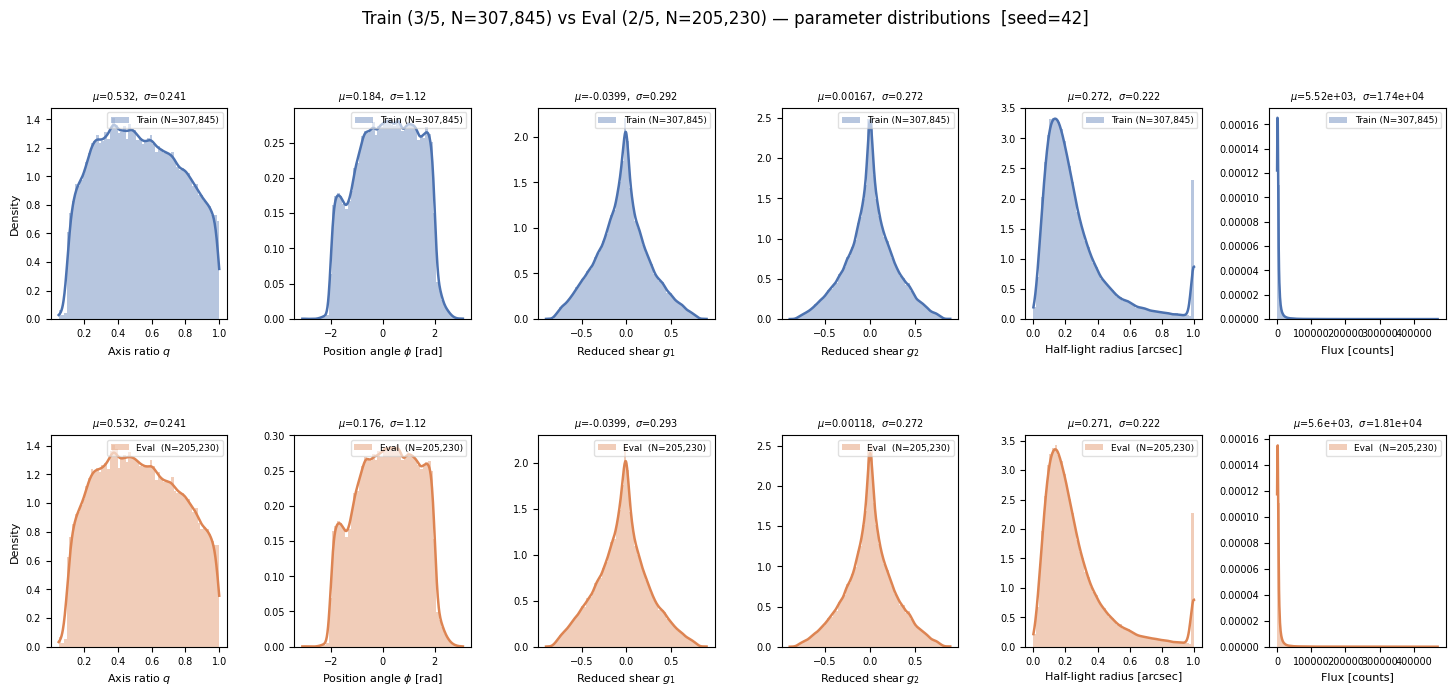

Saved distribution plot -> /home/adfield/ShearNet/catalog_split_distributions_COSMOS.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

params = [
    ('Q',    q_arr,               r'Axis ratio $q$'),
    ('PHI',  phi_arr,             r'Position angle $\phi$ [rad]'),
    ('G1',   g1_list,             r'Reduced shear $g_1$'),
    ('G2',   g2_list,             r'Reduced shear $g_2$'),
    ('HLR',  hlr_list,            r'Half-light radius [arcsec]'),
    ('FLUX', flux_list,            r'Flux [counts]'),
]

TRAIN_COLOR = '#4C72B0'
EVAL_COLOR  = '#DD8452'
N_BINS = 60

fig = plt.figure(figsize=(18, 7))
fig.suptitle(
    f'Train (3/5, N={n_train:,}) vs Eval (2/5, N={n_eval:,}) — parameter distributions'
    f'  [seed={RANDOM_SEED}]',
    fontsize=12, y=1.02
)
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.55, wspace=0.38)

for col, (name, arr, xlabel) in enumerate(params):
    train_vals = arr[train_idx]
    eval_vals  = arr[eval_idx]

    # Shared bin edges so the two histograms are directly comparable
    lo   = min(train_vals.min(), eval_vals.min())
    hi   = max(train_vals.max(), eval_vals.max())
    bins = np.linspace(lo, hi, N_BINS + 1)
    kde_x = np.linspace(lo, hi, 500)

    for row, (vals, color, split_label) in enumerate([
        (train_vals, TRAIN_COLOR, f'Train (N={n_train:,})'),
        (eval_vals,  EVAL_COLOR,  f'Eval  (N={n_eval:,})'),
    ]):
        ax = fig.add_subplot(gs[row, col])

        ax.hist(vals, bins=bins, density=True, color=color, alpha=0.4,
                label=split_label)

        try:
            kde = gaussian_kde(vals, bw_method='scott')
            ax.plot(kde_x, kde(kde_x), color=color, lw=1.8)
        except np.linalg.LinAlgError:
            pass

        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel('Density' if col == 0 else '', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=6.5, loc='upper right', framealpha=0.6)
        ax.set_title(
            fr'$\mu$={vals.mean():.3g},  $\sigma$={vals.std():.3g}',
            fontsize=7
        )

plt.tight_layout()
plot_path = os.path.join(out_dir, "catalog_split_distributions_COSMOS.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved distribution plot -> {plot_path}")

In [8]:
from scipy.stats import ks_2samp

print(f"{'Param':<8}  {'KS stat':>10}  {'p-value':>12}  {'Pass (p>0.05)?'}")
print('-' * 52)
for name, arr, _ in params:
    stat, pval = ks_2samp(arr[train_idx], arr[eval_idx])
    flag = '✓' if pval > 0.05 else '✗  <-- check this!'
    print(f"{name:<8}  {stat:>10.4f}  {pval:>12.4f}  {flag}")

Param        KS stat       p-value  Pass (p>0.05)?
----------------------------------------------------
Q             0.0020        0.6954  ✓
PHI           0.0042        0.0236  ✗  <-- check this!
G1            0.0022        0.6062  ✓
G2            0.0025        0.4351  ✓
HLR           0.0022        0.5617  ✓
FLUX          0.0033        0.1472  ✓
